In [1]:
import pathlib
import tempfile
import zipfile
from datetime import datetime, timedelta
import numpy as np
from numpy import ma
import xarray as xr

from matplotlib import pyplot as plt
import cartopy.crs as ccrs


In [2]:
ec_path = pathlib.Path("/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/")

In [3]:
ec_files = sorted(list(ec_path.rglob("*_20240811*.ZIP")))

In [4]:
ec_files

[PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T005632Z_20250904T204347Z_01152H.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T010821Z_20250904T213615Z_01153A.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T011957Z_20250904T210658Z_01153B.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T022908Z_20250904T210536Z_01153H.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T024057Z_20250904T210729Z_01154A.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2a/CPR_CLD_2A/2024/08/11/ECA_EXBA_CPR_CLD_2A_20240811T025233Z_20250904T212827Z_01154B.ZIP'),
 PosixPath('/gws/nopw/j04/eo_shared_data

In [5]:
zf = zipfile.ZipFile(ec_files[0])

with tempfile.TemporaryDirectory() as tempdir:
    zf.extractall(tempdir)
    ec_file = list(pathlib.Path(tempdir).glob("*.h5"))[0]
    ec_ds = xr.open_datatree(ec_file).ScienceData.to_dataset().load()

/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'datamet' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/home/users/wkjones/miniforge3/envs/tobac_flow/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
 

In [6]:
ec_ds

<xarray.Dataset> Size: 122MB
Dimensions:                                           (along_track: 4991,
                                                       CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/51)
    time                                              (along_track) datetime64[ns] 40kB ...
    latitude                                          (along_track) float64 40kB ...
    longitude                                         (along_track) float64 40kB ...
    height                                            (along_track, CPR_height) float32 4MB ...
    geoid_offset                                      (along_track) float32 20kB ...
    surface_elevation                                 (along_track) float32 20kB ...
    ...                                                ...
    liquid_effective_radius                           (along_track, CPR_height) float32 4MB ...
    liquid_effective_radius_relative_error            (along_track, CPR_height) float32 4MB ...
    liquid_water_path                                 (along_track) float32 20kB ...
    liquid_water_path_error                           (along_track) float32 20kB ...
    drizzle_mass_flux                                 (along_track) float32 20kB ...
    drizzle_mass_flux_log_error                       (along_track) float32 20kB ...

In [7]:
def load_ec_archive(ec_file):
    zf = zipfile.ZipFile(ec_file)

    with tempfile.TemporaryDirectory() as tempdir:
        zf.extractall(tempdir)
        f = list(pathlib.Path(tempdir).glob("*.h5"))[0]
        ec_ds = xr.open_datatree(f).ScienceData.to_dataset().load()
    
    return ec_ds

In [8]:
dcc_path = pathlib.Path("/work/scratch-nopw2/wkjones/orcestra_linked/")
dcc_ds = xr.open_dataset(list(dcc_path.rglob("*_S20240811*"))[0])

stats_path = pathlib.Path("/work/scratch-nopw2/wkjones/")
stats_file = list(stats_path.glob("*_S20240810*"))[0]
stats_ds = xr.open_dataset(list(stats_path.glob("*_S20240810*"))[0])


In [9]:
dcc_ds

<xarray.Dataset> Size: 19GB
Dimensions:                       (y: 2287, x: 3623, t: 96, core: 3965,
                                   anvil: 1799, core_step: 17399,
                                   thick_anvil_step: 27935,
                                   thin_anvil_step: 32562)
Coordinates:
  * t                             (t) datetime64[ns] 768B 2024-08-11T00:12:42...
  * y                             (y) float64 18kB -3.429e+06 ... 3.429e+06
  * x                             (x) float64 29kB 5.434e+06 ... -5.434e+06
    longitude                     (y, x) float64 66MB ...
    latitude                      (y, x) float64 66MB ...
  * core                          (core) int32 16kB 3930 3939 3958 ... 7985 7986
  * anvil                         (anvil) int32 7kB 24 101 149 ... 3544 3556
  * core_step                     (core_step) int32 70kB 1 2 3 ... 17398 17399
  * thick_anvil_step              (thick_anvil_step) int32 112kB 1 2 ... 27935
  * thin_anvil_step               (thin_anvil_step) int32 130kB 1 2 ... 32562
Data variables: (12/77)
    lat                           (y, x) float32 33MB ...
    lon                           (y, x) float32 33MB ...
    area                          (y, x) float32 33MB ...
    core_label                    (t, y, x) int32 3GB ...
    thick_anvil_label             (t, y, x) int32 3GB ...
    thin_anvil_label              (t, y, x) int32 3GB ...
    ...                            ...
    thick_anvil_step_bt_max       (thick_anvil_step) float32 112kB ...
    thick_anvil_step_bt_min       (thick_anvil_step) float32 112kB ...
    thin_anvil_step_bt_mean       (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_std        (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_max        (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_min        (thin_anvil_step) float32 130kB ...

In [10]:
from sklearn.neighbors import BallTree

In [11]:
wh_finite_latlon = np.logical_and(
    np.isfinite(dcc_ds.latitude.values.ravel()), 
    np.isfinite(dcc_ds.longitude.values.ravel()), 
)

In [12]:
sev_ll_tree = BallTree(
    np.radians(np.stack(
        [
            dcc_ds.latitude.values.ravel()[wh_finite_latlon], 
            dcc_ds.longitude.values.ravel()[wh_finite_latlon]
        ], axis=1
    )), 
    metric="haversine", 
)

In [13]:
sev_ll_tree

In [14]:
distances, neighbours = sev_ll_tree.query(
    np.radians(np.stack(
        [
            ec_ds.latitude.values.ravel(), 
            ec_ds.longitude.values.ravel()
        ], axis=1
    ))
)

distances = np.degrees(distances.ravel()) * 1.11e2 # Convert distances to km
neighbours = neighbours.ravel()

In [15]:
wh_colocated = distances < 10

In [16]:
wh_colocated

array([False, False, False, ...,  True,  True,  True])

In [17]:
ec_ds_coloc = ec_ds.isel(along_track=wh_colocated)

In [18]:
ec_ds_coloc

<xarray.Dataset> Size: 32MB
Dimensions:                                           (along_track: 1313,
                                                       CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/51)
    time                                              (along_track) datetime64[ns] 11kB ...
    latitude                                          (along_track) float64 11kB ...
    longitude                                         (along_track) float64 11kB ...
    height                                            (along_track, CPR_height) float32 1MB ...
    geoid_offset                                      (along_track) float32 5kB ...
    surface_elevation                                 (along_track) float32 5kB ...
    ...                                                ...
    liquid_effective_radius                           (along_track, CPR_height) float32 1MB ...
    liquid_effective_radius_relative_error            (along_track, CPR_height) float32 1MB ...
    liquid_water_path                                 (along_track) float32 5kB ...
    liquid_water_path_error                           (along_track) float32 5kB ...
    drizzle_mass_flux                                 (along_track) float32 5kB ...
    drizzle_mass_flux_log_error                       (along_track) float32 5kB ...

In [19]:
np.where(wh_finite_latlon)[0]

array([    408,     409,     410, ..., 8285390, 8285391, 8285392])

In [20]:
y_coloc, x_coloc = np.unravel_index(np.where(wh_finite_latlon)[0][neighbours[wh_colocated]], shape=dcc_ds.lat.shape)

In [21]:
dcc_ds

<xarray.Dataset> Size: 19GB
Dimensions:                       (y: 2287, x: 3623, t: 96, core: 3965,
                                   anvil: 1799, core_step: 17399,
                                   thick_anvil_step: 27935,
                                   thin_anvil_step: 32562)
Coordinates:
  * t                             (t) datetime64[ns] 768B 2024-08-11T00:12:42...
  * y                             (y) float64 18kB -3.429e+06 ... 3.429e+06
  * x                             (x) float64 29kB 5.434e+06 ... -5.434e+06
    longitude                     (y, x) float64 66MB inf inf inf ... inf inf
    latitude                      (y, x) float64 66MB inf inf inf ... inf inf
  * core                          (core) int32 16kB 3930 3939 3958 ... 7985 7986
  * anvil                         (anvil) int32 7kB 24 101 149 ... 3544 3556
  * core_step                     (core_step) int32 70kB 1 2 3 ... 17398 17399
  * thick_anvil_step              (thick_anvil_step) int32 112kB 1 2 ... 27935
  * thin_anvil_step               (thin_anvil_step) int32 130kB 1 2 ... 32562
Data variables: (12/77)
    lat                           (y, x) float32 33MB ...
    lon                           (y, x) float32 33MB ...
    area                          (y, x) float32 33MB ...
    core_label                    (t, y, x) int32 3GB ...
    thick_anvil_label             (t, y, x) int32 3GB ...
    thin_anvil_label              (t, y, x) int32 3GB ...
    ...                            ...
    thick_anvil_step_bt_max       (thick_anvil_step) float32 112kB ...
    thick_anvil_step_bt_min       (thick_anvil_step) float32 112kB ...
    thin_anvil_step_bt_mean       (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_std        (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_max        (thin_anvil_step) float32 130kB ...
    thin_anvil_step_bt_min        (thin_anvil_step) float32 130kB ...

In [22]:
thick_anvil_labels = dcc_ds.thick_anvil_label.load()
thick_anvil_labels = dcc_ds.thick_anvil_label.assign_coords(
    dict(
        x=dcc_ds.thick_anvil_label.x,
        y=dcc_ds.thick_anvil_label.y,
    )
)

In [23]:
colocated_anvil_labels = thick_anvil_labels.sel(
    t=ec_ds_coloc.time,
    y=xr.DataArray(y_coloc, dims="along_track", coords=dict(along_track=ec_ds_coloc.along_track)), 
    x=xr.DataArray(x_coloc, dims="along_track", coords=dict(along_track=ec_ds_coloc.along_track)), 
    method="nearest"
)

In [24]:
colocated_anvil_labels

<xarray.DataArray 'thick_anvil_label' (along_track: 1313)> Size: 5kB
array([0, 0, 0, ..., 0, 0, 0], dtype=int32)
Coordinates:
    t            (along_track) datetime64[ns] 11kB 2024-08-11T01:12:42.307000...
    longitude    (along_track) float64 11kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    latitude     (along_track) float64 11kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    x            (along_track) float64 11kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    y            (along_track) float64 11kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * along_track  (along_track) int64 11kB 0 1 2 3 4 ... 1308 1309 1310 1311 1312
Attributes:
    long_name:      labels for detected thick anvil regions
    cell_measures:  area: area
    units:          
    standard_name:  thick_anvil_label

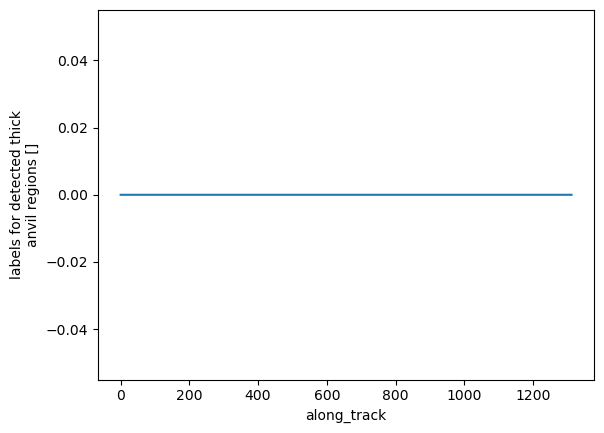

In [25]:
colocated_anvil_labels.plot()

In [26]:
np.unique(colocated_anvil_labels)

array([0], dtype=int32)

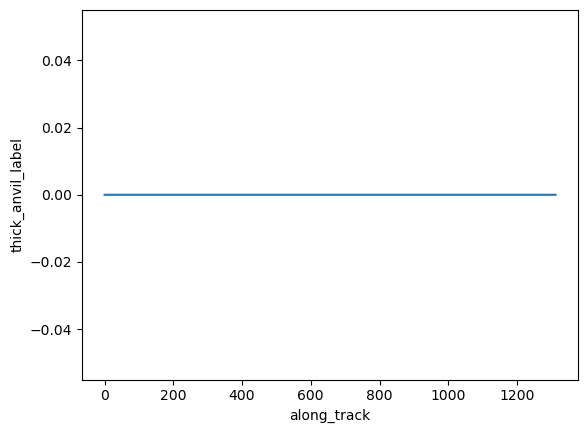

In [27]:
 (colocated_anvil_labels==2188).plot()

In [28]:
thick_anvil_step_labels = dcc_ds.thick_anvil_step_label.load()
thick_anvil_step_labels = thick_anvil_step_labels.assign_coords(
    dict(
        x=dcc_ds.thick_anvil_label.x,
        y=dcc_ds.thick_anvil_label.y,
    )
)

In [29]:
colocated_anvil_step_labels = thick_anvil_step_labels.sel(
    t=ec_ds_coloc.time,
    y=xr.DataArray(y_coloc, dims="along_track", coords=dict(along_track=ec_ds_coloc.along_track)), 
    x=xr.DataArray(x_coloc, dims="along_track", coords=dict(along_track=ec_ds_coloc.along_track)), 
    method="nearest"
)

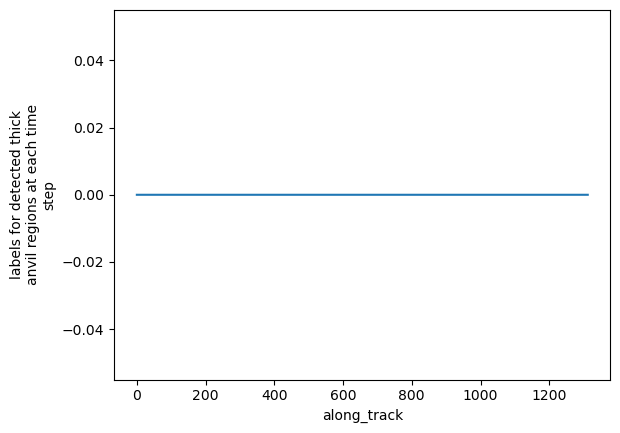

In [30]:
colocated_anvil_step_labels.plot()

In [31]:
np.unique(colocated_anvil_step_labels)

array([0], dtype=int32)

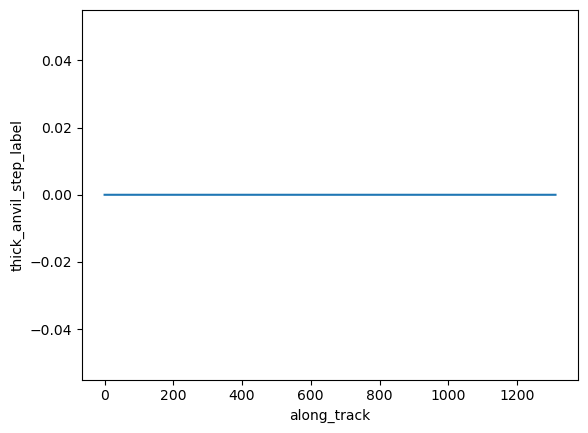

In [32]:
 (colocated_anvil_step_labels==47533).plot()

In [33]:
from scipy import ndimage as ndi

In [34]:
ndi.binary_dilation(colocated_anvil_step_labels==47533, iterations=100)

array([False, False, False, ..., False, False, False])

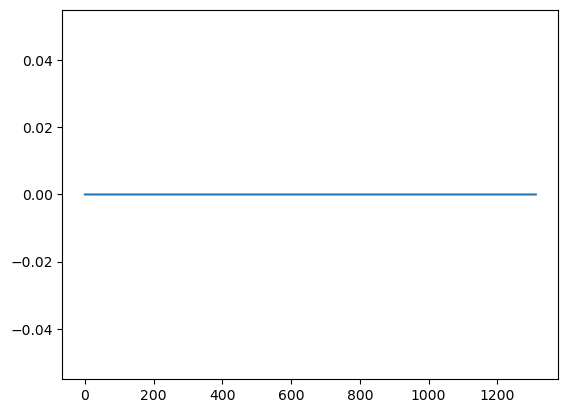

In [35]:
padded_region = ndi.binary_dilation(colocated_anvil_step_labels==47533, iterations=100)
plt.plot(padded_region)

In [36]:
ec_ds_coloc.isel(along_track=padded_region)

<xarray.Dataset> Size: 0B
Dimensions:                                           (along_track: 0,
                                                       CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/51)
    time                                              (along_track) datetime64[ns] 0B ...
    latitude                                          (along_track) float64 0B 
    longitude                                         (along_track) float64 0B 
    height                                            (along_track, CPR_height) float32 0B ...
    geoid_offset                                      (along_track) float32 0B 
    surface_elevation                                 (along_track) float32 0B 
    ...                                                ...
    liquid_effective_radius                           (along_track, CPR_height) float32 0B ...
    liquid_effective_radius_relative_error            (along_track, CPR_height) float32 0B ...
    liquid_water_path                                 (along_track) float32 0B 
    liquid_water_path_error                           (along_track) float32 0B 
    drizzle_mass_flux                                 (along_track) float32 0B 
    drizzle_mass_flux_log_error                       (along_track) float32 0B

In [37]:
stats_ds

<xarray.Dataset> Size: 245MB
Dimensions:                                      (core: 212782, anvil: 58592,
                                                  thick_anvil_step: 1151260,
                                                  core_step: 950514,
                                                  thin_anvil_step: 1249512)
Coordinates:
  * core                                         (core) int32 851kB 119 ... 2...
  * anvil                                        (anvil) int32 234kB 12 ... 9...
  * core_step                                    (core_step) int32 4MB 6 ... ...
  * thick_anvil_step                             (thick_anvil_step) int32 5MB ...
  * thin_anvil_step                              (thin_anvil_step) int32 5MB ...
    y_image                                      int64 8B ...
    x_image                                      int64 8B ...
Data variables: (12/144)
    core_edge_label_flag                         (core) bool 213kB ...
    thick_anvil_start_label_flag                 (anvil) bool 59kB ...
    thick_anvil_step_area                        (thick_anvil_step) float32 5MB ...
    core_step_x                                  (core_step) float32 4MB ...
    core_step_bt_std                             (core_step) float32 4MB ...
    thick_anvil_step_y                           (thick_anvil_step) float32 5MB ...
    ...                                           ...
    anvil_no_growth_flag                         (anvil) bool 59kB ...
    anvil_no_initial_core_flag                   (anvil) bool 59kB ...
    core_is_valid                                (core) bool 213kB ...
    anvil_invalid_core_flag                      (anvil) bool 59kB ...
    thick_anvil_is_valid                         (anvil) bool 59kB ...
    thin_anvil_is_valid                          (anvil) bool 59kB ...

In [38]:
stats_ds.thick_anvil_start_t.min()

<xarray.DataArray 'thick_anvil_start_t' ()> Size: 8B
array('2024-08-10T00:12:42.298000000', dtype='datetime64[ns]')
Coordinates:
    y_image  int64 8B ...
    x_image  int64 8B ...

In [39]:
2188 in stats_ds.anvil

True

In [40]:
np.isin([2188, 4789, 4925, 5086, 5257, 5267], stats_ds.anvil)

array([ True, False, False, False, False, False])

In [41]:
from pyproj import Geod

g = Geod(ellps='GRS80')

In [42]:
def get_overpass_attrs(
    overpass_slice: xr.Dataset, stats_ds: xr.Dataset, anvil_id: int
) -> dict:
    if anvil_id not in stats_ds.anvil:
        raise ValueError(f'Anvil {anvil_id} not found in stats dataset')

    anvil_ds = stats_ds.sel(anvil=anvil_id)
    anvil_ds = anvil_ds.isel(
        core=anvil_ds.core_anvil_index == anvil_id, 
        thick_anvil_step=anvil_ds.thick_anvil_step_anvil_index == anvil_id
    )

    anvil_is_valid = anvil_ds.thick_anvil_is_valid.item()
    mean_overpass_time = overpass_slice.time.mean().values
    time_from_init = mean_overpass_time - anvil_ds.thick_anvil_start_t.values
    prop_from_init = time_from_init / anvil_ds.thick_anvil_lifetime.values
    anvil_core_count = anvil_ds.anvil_core_count.item()
    anvil_core_intensity = anvil_ds.core_max_cooling_rate.max().item()
    anvil_max_area = anvil_ds.thick_anvil_max_area.item()
    anvil_min_bt = anvil_ds.thick_anvil_bt_min.item()
    anvil_lifetime_stage = ["growing", "maturing", "dissipating"][
        0 if mean_overpass_time < anvil_ds.thick_anvil_min_bt_t else 1 if mean_overpass_time < anvil_ds.thick_anvil_max_area_t else 2
    ]

    nearest_overpass_step = np.abs(anvil_ds.thick_anvil_step_t - mean_overpass_time).idxmin().item()

    from pyproj import Geod

    g = Geod(ellps='GRS80')

    min_overpass_distance = g.inv(
        np.repeat(anvil_ds.thick_anvil_step_lon.sel(thick_anvil_step=nearest_overpass_step).item(), overpass_slice.along_track.size), 
        np.repeat(anvil_ds.thick_anvil_step_lat.sel(thick_anvil_step=nearest_overpass_step).item(), overpass_slice.along_track.size), 
        overpass_slice.longitude.values, 
        overpass_slice.latitude.values
    )[-1].min()/1e3

    return dict(
        anvil_id=anvil_id, 
        anvil_is_valid=str(anvil_is_valid), 
        mean_overpass_time=str(mean_overpass_time),
        time_from_init=int(time_from_init)/1e9, 
        prop_from_init=prop_from_init, 
        anvil_core_count=anvil_core_count, 
        anvil_core_intensity=anvil_core_intensity, 
        anvil_max_area=anvil_max_area, 
        anvil_min_bt=anvil_min_bt, 
        anvil_lifetime_stage=anvil_lifetime_stage, 
        min_overpass_distance=min_overpass_distance, 
    )

In [43]:
save_path = pathlib.Path("/work/scratch-nopw2/wkjones/cloudsat_overpasses")
save_path.mkdir(exist_ok=True)

In [44]:
def output_colocated_ec_slices(ec_ds_coloc, colocated_anvil_labels, stats_ds, save_path, product, earthcare_file, stats_file, mask_file):
    for anvil_id in np.unique(colocated_anvil_labels):
        if anvil_id > 0:
            overpass_mask = ndi.label(ndi.binary_dilation(
                colocated_anvil_labels==anvil_id, iterations=200
            ))[0]
    
            for label in np.unique(overpass_mask):
                if label > 0:
                    overpass_slice = ec_ds_coloc.isel(along_track = overpass_mask==label)
                    try:
                        overpass_slice = overpass_slice.assign_attrs(
                            get_overpass_attrs(overpass_slice, stats_ds, anvil_id)
                        )
                        overpass_slice = overpass_slice.assign_attrs({
                            "earthcare_file":earthcare_file.stem, 
                            "stats_file":stats_file.name,
                            "mask_file":mask_file.name,
                        })
                    except ValueError:
                        pass
                    else:
                        mean_time = datetime.fromisoformat(overpass_slice.mean_overpass_time).strftime("%Y%m%d%H%M%S")
                        save_name = f'{product}_o{earthcare_file.stem.split("_")[-1]}_t{mean_time}_a{anvil_id}.nc'
                        print(save_name)
                        # del overpass_slice.time.attrs["units"]
                        overpass_slice.to_netcdf(save_path / save_name, mode="a")
                        

In [45]:
dcc_path

PosixPath('/work/scratch-nopw2/wkjones/orcestra_linked')

In [46]:
dcc_file = sorted(list(dcc_path.rglob(f'detected_dccs_*.nc')))[0]

In [47]:
dcc_file

PosixPath('/work/scratch-nopw2/wkjones/orcestra_linked/2024/detected_dccs_MSG_S20240810_000000_E20240811_000000_X0044_3667_Y0712_2999.nc')

In [48]:
dcc_file.name[19:27]

'20240810'

In [49]:
date = datetime(2024,8,10)

In [50]:
save_path = pathlib.Path("/work/scratch-nopw2/wkjones/ec_overpasses")
save_path.mkdir(exist_ok=True)

ec_path = pathlib.Path("/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B")

for dcc_file in sorted(list(dcc_path.rglob(f'detected_dccs_*.nc'))):
    print(dcc_file.name)
    with xr.open_dataset(dcc_file) as dcc_ds:
        yyyymmdd = dcc_file.name[19:27]
        date = datetime.strptime(yyyymmdd, "%Y%m%d")
        
        ec_files = sorted(list((ec_path/date.strftime("%Y/%m/%d")).glob("*.ZIP")))
        for f in ec_files:
            # ec_ds = xr.concat(objs=[load_ec_archive(f) for f in ec_files], dim="along_track")
            print(f)
            ec_ds = load_ec_archive(f)
            
            distances, neighbours = sev_ll_tree.query(
                np.radians(np.stack(
                    [
                        ec_ds.latitude.values.ravel(), 
                        ec_ds.longitude.values.ravel()
                    ], axis=1
                ))
            )
            
            distances = np.degrees(distances.ravel()) * 1.11e2 # Convert distances to km
            neighbours = neighbours.ravel()

            wh_colocated = distances < 10
            ec_ds = ec_ds.isel(along_track=wh_colocated)
            idy_coloc, idx_coloc = np.unravel_index(
                np.where(wh_finite_latlon)[0][neighbours[wh_colocated]], 
                shape=dcc_ds.lat.shape
            )

            y_coloc = dcc_ds.y.values.ravel()[idy_coloc]
            x_coloc = dcc_ds.x.values.ravel()[idx_coloc]
            
            thick_anvil_labels = dcc_ds.thick_anvil_label.load()
            thick_anvil_labels = dcc_ds.thick_anvil_label.assign_coords(
                dict(
                    x=dcc_ds.thick_anvil_label.x,
                    y=dcc_ds.thick_anvil_label.y,
                )
            )

            colocated_anvil_labels = thick_anvil_labels.sel(
                t=ec_ds.time,
                y=xr.DataArray(y_coloc, dims="along_track", coords=dict(along_track=ec_ds.along_track)), 
                x=xr.DataArray(x_coloc, dims="along_track", coords=dict(along_track=ec_ds.along_track)), 
                method="nearest"
            )
            
            if any(colocated_anvil_labels):
                # try:
                output_colocated_ec_slices(ec_ds, colocated_anvil_labels, stats_ds, save_path, ec_path.parts[-1], f, stats_file, dcc_file)
                # except ValueError:
                #     pass
            
            # break

            ec_ds.close()
            del ec_ds




detected_dccs_MSG_S20240810_000000_E20240811_000000_X0044_3667_Y0712_2999.nc
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/10/ECA_EXBA_ACM_CAP_2B_20240810T090733Z_20250905T193446Z_01142F.ZIP
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/10/ECA_EXBA_ACM_CAP_2B_20240810T101646Z_20250905T072040Z_01143D.ZIP
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/10/ECA_EXBA_ACM_CAP_2B_20240810T215119Z_20250905T103324Z_01150H.ZIP
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/10/ECA_EXBA_ACM_CAP_2B_20240810T221444Z_20250905T201349Z_01151B.ZIP
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/10/ECA_EXBA_ACM_CAP_2B_20240810T232355Z_20250905T131006Z_01151H.ZIP
detected_dccs_MSG_S20240811_000000_E20240812_000000_X0044_3667_Y0712_2999.nc
/gws/nopw/j04/eo_shared_data_vol1/satellite/earthcare/L2b/ACM_CAP_2B/2024/08/11/ECA_EXBA_ACM_CAP_2B_20240811T093737Z_2025

KeyboardInterrupt: 

In [52]:
xr.open_dataset(save_path/"ACM_CAP_2B_o01158E_t20240811094414_a101.nc")

KeyboardInterrupt: 

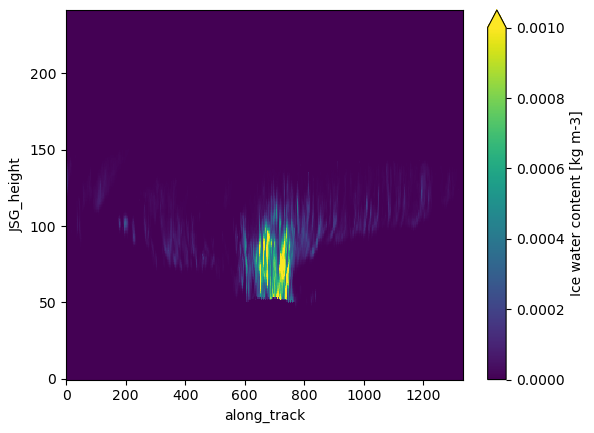

In [82]:
xr.open_dataset(save_path/"ACM_CAP_2B_overpass_t20240811094414_a101.nc").ice_water_content.T[::-1].plot(vmin=0, vmax=0.001)


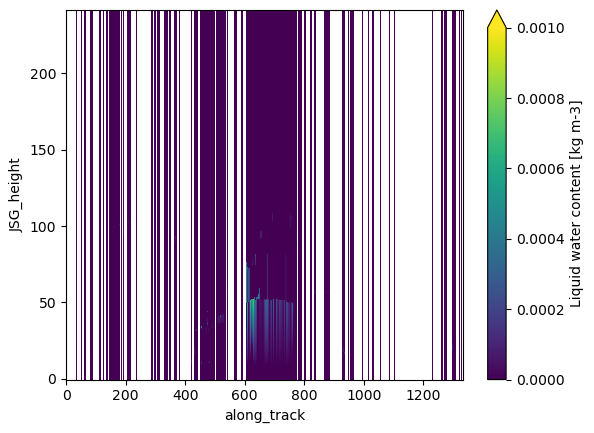

In [83]:
xr.open_dataset(save_path/"ACM_CAP_2B_overpass_t20240811094414_a101.nc").liquid_water_content.T[::-1].plot(vmin=0, vmax=0.001)


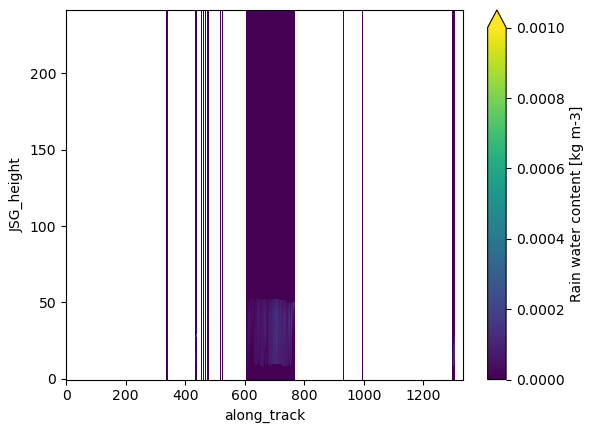

In [84]:
xr.open_dataset(save_path/"ACM_CAP_2B_overpass_t20240811094414_a101.nc").rain_water_content.T[::-1].plot(vmin=0, vmax=0.001)


In [105]:
ec_path.parts[-1]

'ACM_CAP_2B'

In [94]:
ec_ds.latitude

<xarray.DataArray 'latitude' (along_track: 1688)> Size: 14kB
array([-22.42646766, -22.43541483, -22.44436147, ..., -37.90364655,
       -37.91215555, -37.92066475])
Dimensions without coordinates: along_track
Attributes:
    long_name:  Latitude
    units:      degree_north

In [90]:
np.any(colocated_anvil_labels)

<xarray.DataArray 'thick_anvil_label' ()> Size: 1B
array(False)

In [57]:
wh_finite_latlon.shape

(8285801,)

In [58]:
dcc_ds.y.shape

(2287,)

In [60]:
idy_coloc.max()

366

In [63]:
neighbours[wh_colocated]

array([    585,     585,     585, ..., 1117454, 1120725, 1120725])